In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("CKD.csv")

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,2.0,76.459948,c,3.0,0.0,normal,abnormal,notpresent,notpresent,148.112676,...,38.868902,8408.191126,4.705597,no,no,no,yes,yes,no,yes
1,3.0,76.459948,c,2.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,34.000000,12300.000000,4.705597,no,no,no,yes,poor,no,yes
2,4.0,76.459948,a,1.0,0.0,normal,normal,notpresent,notpresent,99.000000,...,34.000000,8408.191126,4.705597,no,no,no,yes,poor,no,yes
3,5.0,76.459948,d,1.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,38.868902,8408.191126,4.705597,no,no,no,yes,poor,yes,yes
4,5.0,50.000000,c,0.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,36.000000,12400.000000,4.705597,no,no,no,yes,poor,no,yes


In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (399, 25)

Column Names:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hrmo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [3]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hrmo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [4]:
print("Classification Counts:")
print(df["classification"].value_counts())

Classification Counts:
classification
yes    249
no     150
Name: count, dtype: int64


In [5]:
X = df.drop("classification", axis=1)
y = df["classification"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   age         bp sg   al   su     rbc        pc         pcc          ba  \
0  2.0  76.459948  c  3.0  0.0  normal  abnormal  notpresent  notpresent   
1  3.0  76.459948  c  2.0  0.0  normal    normal  notpresent  notpresent   
2  4.0  76.459948  a  1.0  0.0  normal    normal  notpresent  notpresent   
3  5.0  76.459948  d  1.0  0.0  normal    normal  notpresent  notpresent   
4  5.0  50.000000  c  0.0  0.0  normal    normal  notpresent  notpresent   

          bgr  ...       hrmo        pcv            wc        rc  htn  dm  \
0  148.112676  ...  12.518156  38.868902   8408.191126  4.705597   no  no   
1  148.112676  ...  10.700000  34.000000  12300.000000  4.705597   no  no   
2   99.000000  ...  12.000000  34.000000   8408.191126  4.705597   no  no   
3  148.112676  ...   8.100000  38.868902   8408.191126  4.705597   no  no   
4  148.112676  ...  11.800000  36.000000  12400.000000  4.705597   no  no   

   cad  appet    pe  ane  
0   no    yes   yes   no  
1   no    ye

In [6]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)
print(X.head())

Shape after encoding: (399, 27)
   age         bp   al   su         bgr         bu        sc         sod  \
0  2.0  76.459948  3.0  0.0  148.112676  57.482105  3.077356  137.528754   
1  3.0  76.459948  2.0  0.0  148.112676  22.000000  0.700000  137.528754   
2  4.0  76.459948  1.0  0.0   99.000000  23.000000  0.600000  138.000000   
3  5.0  76.459948  1.0  0.0  148.112676  16.000000  0.700000  138.000000   
4  5.0  50.000000  0.0  0.0  148.112676  25.000000  0.600000  137.528754   

        pot       hrmo  ...  rbc_normal  pc_normal  pcc_present  ba_present  \
0  4.627244  12.518156  ...        True      False        False       False   
1  4.627244  10.700000  ...        True       True        False       False   
2  4.400000  12.000000  ...        True       True        False       False   
3  3.200000   8.100000  ...        True       True        False       False   
4  4.627244  11.800000  ...        True       True        False       False   

   htn_yes  dm_yes  cad_yes  appet_y

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (319, 27)
Testing data: (80, 27)


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


C:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['no' 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'yes'
 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'no' 'yes' 'yes' 'no'
 'yes' 'no' 'no' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'yes' 'no' 'yes' 'yes'
 'yes' 'yes' 'yes' 'yes' 'no' 'no' 'yes' 'no' 'no' 'yes' 'yes' 'no' 'yes'
 'no' 'yes' 'yes' 'yes' 'no' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'no' 'no'
 'no' 'yes' 'no' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'no' 'yes' 'no'
 'yes' 'yes' 'no']


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9875
Accuracy Percentage: 98.75 %


In [12]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          no       1.00      0.97      0.98        30
         yes       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[29  1]
 [ 0 50]]


In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [16]:
dt_pred = dt_model.predict(X_test)

print("Decision Tree Predictions:")
print(dt_pred)

Decision Tree Predictions:
['no' 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'yes'
 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'no' 'yes' 'yes' 'no'
 'yes' 'no' 'no' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'yes' 'no' 'yes' 'yes'
 'yes' 'yes' 'yes' 'yes' 'no' 'no' 'yes' 'no' 'no' 'yes' 'yes' 'no' 'yes'
 'no' 'yes' 'yes' 'yes' 'no' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'no' 'no'
 'no' 'yes' 'no' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'no' 'yes' 'no'
 'yes' 'yes' 'no']


In [17]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Accuracy Percentage:", dt_accuracy * 100, "%")

Decision Tree Accuracy: 0.9875
Accuracy Percentage: 98.75 %


In [18]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

          no       1.00      0.97      0.98        30
         yes       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



In [19]:
dt_cm = confusion_matrix(y_test, dt_pred)

print("Decision Tree Confusion Matrix:")
print(dt_cm)


Decision Tree Confusion Matrix:
[[29  1]
 [ 0 50]]


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [21]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred)


Random Forest Predictions:
['no' 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'yes'
 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'no' 'no' 'yes' 'no'
 'yes' 'no' 'no' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'yes' 'no' 'yes' 'yes'
 'yes' 'yes' 'yes' 'yes' 'no' 'no' 'no' 'no' 'no' 'yes' 'yes' 'no' 'yes'
 'no' 'yes' 'yes' 'yes' 'no' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'no' 'no'
 'no' 'yes' 'no' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'no' 'yes' 'no'
 'yes' 'yes' 'no']


In [22]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Accuracy Percentage:", rf_accuracy * 100, "%")

Random Forest Accuracy: 0.9875
Accuracy Percentage: 98.75 %


In [23]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

          no       0.97      1.00      0.98        30
         yes       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [24]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[30  0]
 [ 1 49]]


In [25]:
results = {
    "Logistic Regression": accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

print("Model Accuracy Comparison:\n")

for model_name, score in results.items():
    print(model_name, ":", round(score * 100, 2), "%")

Model Accuracy Comparison:

Logistic Regression : 98.75 %
Decision Tree : 98.75 %
Random Forest : 98.75 %


In [26]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Best Accuracy:", round(results[best_model] * 100, 2), "%")

Best Model: Logistic Regression
Best Accuracy: 98.75 %


In [27]:
print("Final Conclusion:")
print(f"The best performing model is {best_model} with an accuracy of {results[best_model] * 100:.2f}%.")
print("This model can be considered the best among the three classification models tested.")

Final Conclusion:
The best performing model is Logistic Regression with an accuracy of 98.75%.
This model can be considered the best among the three classification models tested.


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.9875,98.75
1,Decision Tree,0.9875,98.75
2,Random Forest,0.9875,98.75


In [29]:
comparison.to_csv("model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!


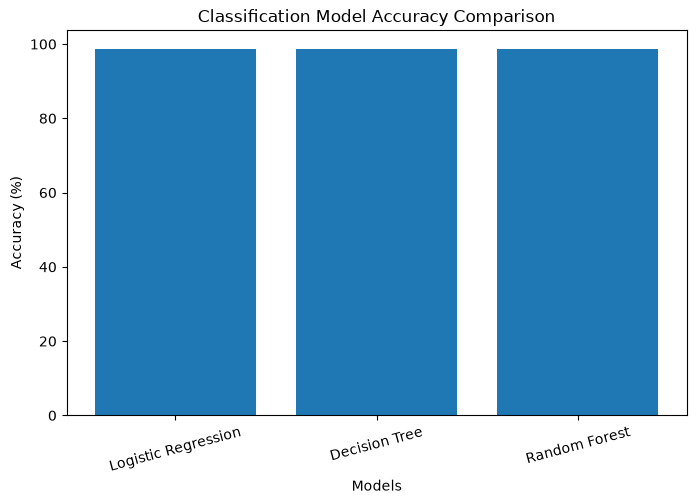

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["Accuracy (%)"])

plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.show()

In [31]:
print("===== FINAL MODEL SUMMARY =====")
print("Dataset: CKD.csv")
print("Problem: Chronic Kidney Disease Classification")
print("Models Tested:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")
print()
print("Best Model:", best_model)
print("Best Accuracy:", round(results[best_model] * 100, 2), "%")

===== FINAL MODEL SUMMARY =====
Dataset: CKD.csv
Problem: Chronic Kidney Disease Classification
Models Tested:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Best Model: Logistic Regression
Best Accuracy: 98.75 %
